# Gold Price Forecasting: Preprocessing, Modeling & Time-Series Validation (Corrected)

**Goal:** predict tomorrow's gold closing price. Every model (Linear, Ridge, XGBoost, SARIMAX, LSTM) is evaluated with the **same rolling-window time-series cross-validation**, plus a **naive baseline** ("tomorrow = today's close") so we know whether any model adds real value.

### Errors fixed relative to the original notebook
1. **Inconsistent evaluation.** Linear/Ridge used a single 80/20 split while XGBoost/SARIMAX/LSTM used 12 rolling windows, so the final table compared apples to oranges. All models now use identical windows.
2. **Holiday rows broke the target.** Market-closed rows (all NaN) were kept, so `shift(-1)` produced NaN targets and wrong lags. Holiday rows are now dropped *before* creating the target.
3. **Variables overwritten.** The rolling loops reused `X_test`/`y_test`, which broke later checks. Loop variables are now local to functions.
4. **SARIMAX produced a 1-year multi-step forecast** (error compounds, giving R² of -3.3). It now makes honest **one-step-ahead** forecasts using the fitted parameters, with a proper index.
5. **LSTM window misalignment.** Sequences ended one day *before* the prediction day (effectively a 2-day-ahead forecast), and early stopping monitored training loss. Windows now end on the prediction day, and a chronological validation tail is used for early stopping. Seeds are fixed.
6. **Ridge was never tuned.** `alpha` is now chosen with `TimeSeriesSplit` inside each training window.
7. **No baseline.** A naive persistence baseline is added.

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
set_seed()
print("Libraries loaded.")

I0000 00:00:1791305827.142228    7612 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791305828.864169    7612 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Libraries loaded.


## 1. Load data

In [2]:
candidates = ["financial_regression.csv", "Gold_Regression.csv",
              "/mnt/user-data/uploads/Gold_Regression.csv"]
DATA_PATH = next(p for p in candidates if os.path.exists(p))
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, df.shape)
df.head()

Loaded: /mnt/user-data/uploads/Gold_Regression.csv (3904, 47)


,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [3]:
print("Percentage of missing values (raw):")
(df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False).head(12)

Percentage of missing values (raw):


GDP                98.54
CPI                95.49
us_rates_%         95.49
usd_chf             5.38
eur_usd             5.38
sp500 volume        4.74
sp500 open          4.74
nasdaq close        4.74
sp500 high-low      4.74
nasdaq open         4.74
nasdaq high         4.74
nasdaq high-low     4.74
dtype: float64

## 2. Preprocessing & feature engineering

`us_rates_%`, `CPI` and `GDP` are >95% missing (they are published monthly/quarterly), so they are excluded as predictors. 

**Key fix:** rows where the market was closed are entirely NaN. We drop them **first**, so that "tomorrow" means the *next trading day* and lags line up.

In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# FIX: remove market-closed rows BEFORE building target / lags
n_before = len(df)
df = df.dropna(subset=["gold close"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} market-closed rows -> {len(df)} trading days")

# Calendar features
df["DayOfWeek"]  = df["date"].dt.dayofweek
df["Month"]      = df["date"].dt.month
df["Quarter"]    = df["date"].dt.quarter
df["DayOfYear"]  = df["date"].dt.dayofyear
df["IsMonthEnd"] = df["date"].dt.is_month_end.astype(int)

# Target = next trading day's gold close
df["Target_Next_Close"] = df["gold close"].shift(-1)

# Lagged / return features (today's values only; no future information)
df["Close_Lag1"]   = df["gold close"].shift(1)
df["Open_Lag1"]    = df["gold open"].shift(1)
df["Daily_Return"] = (df["gold close"] - df["gold open"]) / df["gold open"]

# The last row has no "tomorrow", so it cannot be used for modeling
model_df = df.dropna(subset=["Target_Next_Close"]).reset_index(drop=True)
print("Modeling dataset:", model_df.shape,
      "|", model_df["date"].min().date(), "to", model_df["date"].max().date())
print("Remaining missing values in market columns:",
      int(model_df.filter(regex="open|high|low|close|volume").isna().sum().sum()))

Dropped 185 market-closed rows -> 3719 trading days
Modeling dataset: (3718, 56) | 2010-01-14 to 2024-10-22
Remaining missing values in market columns: 0


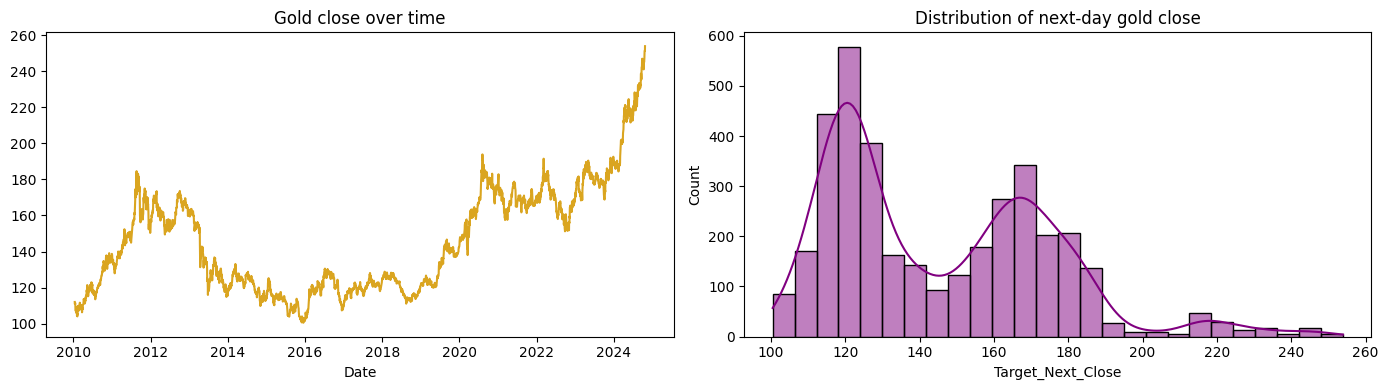

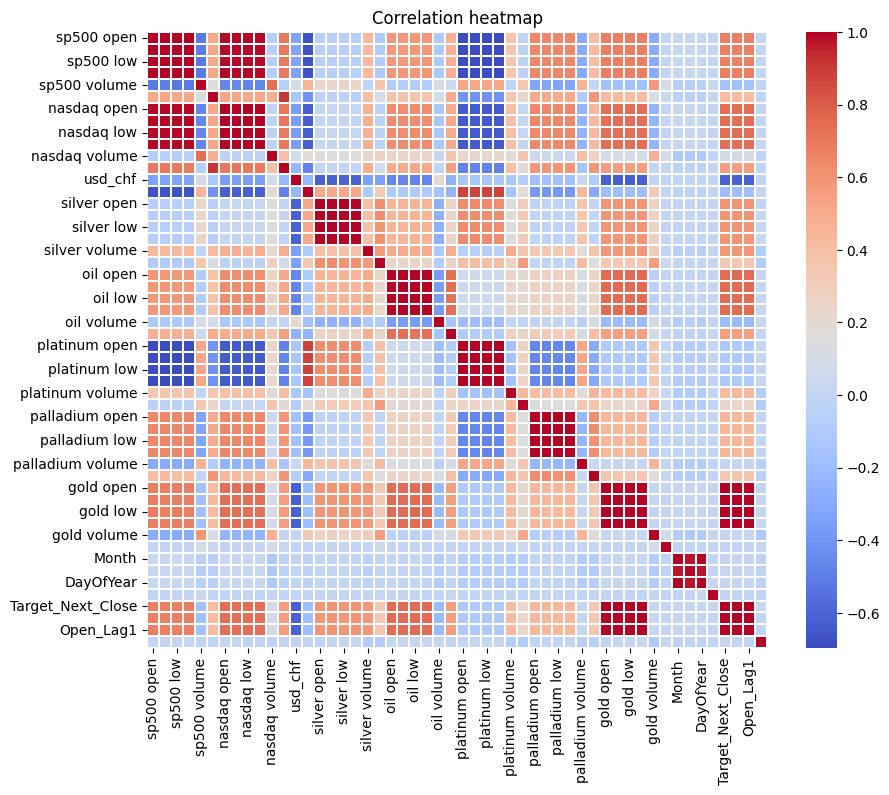

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(model_df["date"], model_df["gold close"], color="goldenrod")
ax[0].set_title("Gold close over time"); ax[0].set_xlabel("Date")
sns.histplot(model_df["Target_Next_Close"], kde=True, color="purple", ax=ax[1])
ax[1].set_title("Distribution of next-day gold close")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(model_df.select_dtypes("number").drop(columns=["us_rates_%","CPI","GDP"]).corr(),
            cmap="coolwarm", linewidths=0.2)
plt.title("Correlation heatmap"); plt.show()

## 3. Features, windows, and metrics

Gold's price level **trends upward** (about 110 in 2010 to about 250 in 2024). That is why a single chronological split is misleading: the test period contains prices the model never saw. Rolling windows (4 years train, 1 year test) give 12 independent out-of-sample evaluations.

In [6]:
features = [
    c for c in model_df.columns
    if c.split(" ")[0] in {"sp500","nasdaq","silver","oil","platinum","palladium","gold"}
] + ["DayOfWeek","Month","Quarter","DayOfYear","IsMonthEnd","Daily_Return"]
print(len(features), "features")

# Smaller feature sets for the sequence / state-space models
seq_features = ["gold close","silver close","oil close","sp500 close","nasdaq close","usd_chf"]
TARGET = "Target_Next_Close"

# Rolling windows: 4 years train -> next year test
windows = [{"train_start": y-4, "train_end": y-1, "test_year": y} for y in range(2012, 2024)]
pd.DataFrame(windows)

47 features


,train_start,train_end,test_year
0,2008,2011,2012
1,2009,2012,2013
2,2010,2013,2014
3,2011,2014,2015
4,2012,2015,2016
5,2013,2016,2017
6,2014,2017,2018
7,2015,2018,2019
8,2016,2019,2020
9,2017,2020,2021


In [7]:
def metrics(y_true, y_pred):
    return (mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred))

def get_window(w):
    yr = model_df["date"].dt.year
    tr = model_df[(yr >= w["train_start"]) & (yr <= w["train_end"])].reset_index(drop=True)
    te = model_df[yr == w["test_year"]].reset_index(drop=True)
    return tr, te

## 4. Model functions
Each function takes `(train, test)` and returns predictions for `test`. Everything (imputer, scaler, tuning) is fit on the training window only.

In [8]:
def predict_naive(train, test):
    """Persistence baseline: tomorrow's close = today's close."""
    return test["gold close"].fillna(train["gold close"].median()).values

def predict_linear(train, test):
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()),
                     ("m", LinearRegression())])
    pipe.fit(train[features], train[TARGET])
    return pipe.predict(test[features])

RIDGE_GRID = {"m__alpha": np.logspace(-2, 3, 12)}
def predict_ridge(train, test):
    """Ridge with alpha chosen by TimeSeriesSplit CV inside the training window."""
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler()),
                     ("m", Ridge())])
    gs = GridSearchCV(pipe, RIDGE_GRID, cv=TimeSeriesSplit(n_splits=5),
                      scoring="neg_mean_squared_error")
    gs.fit(train[features], train[TARGET])
    predict_ridge.last_alpha = gs.best_params_["m__alpha"]
    return gs.predict(test[features])

def predict_xgb(train, test):
    model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         objective="reg:squarederror", random_state=SEED, n_jobs=-1)
    model.fit(train[features], train[TARGET])      # XGBoost handles NaN natively
    return model.predict(test[features])

def predict_sarimax(train, test):
    """One-step-ahead SARIMAX forecasts.
    Parameters are estimated on the training window only; the test observations are then
    appended (refit=False) so each forecast uses all data available up to that day."""
    med = train[seq_features].median()
    Xtr = train[seq_features].fillna(med).reset_index(drop=True)
    Xte = test[seq_features].fillna(med).reset_index(drop=True)
    ytr = train[TARGET].reset_index(drop=True)
    yte = test[TARGET].reset_index(drop=True)
    # appended data must extend the training index
    shift = len(ytr)
    yte.index = Xte.index = pd.RangeIndex(shift, shift + len(yte))

    fit = SARIMAX(ytr, exog=Xtr, order=(1, 1, 1),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    ext = fit.append(yte, exog=Xte, refit=False)
    pred = ext.get_prediction(start=len(ytr), end=len(ytr) + len(yte) - 1).predicted_mean
    return pred.values

In [9]:
SEQ_LEN = 20

def make_sequences(X, y, seq_len):
    """Window i covers rows [i-seq_len+1 .. i] and predicts y[i]  (window ends ON the prediction day)."""
    Xs, ys = [], []
    for i in range(seq_len - 1, len(X)):
        Xs.append(X[i - seq_len + 1: i + 1])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

def predict_lstm(train, test):
    set_seed()
    tf.keras.backend.clear_session()

    imp = SimpleImputer(strategy="median").fit(train[seq_features])
    Xtr = imp.transform(train[seq_features]); Xte = imp.transform(test[seq_features])
    sx = MinMaxScaler().fit(Xtr);  Xtr = sx.transform(Xtr); Xte = sx.transform(Xte)
    sy = MinMaxScaler().fit(train[[TARGET]])
    ytr = sy.transform(train[[TARGET]]).ravel()

    Xs, ys = make_sequences(Xtr, ytr, SEQ_LEN)

    model = Sequential([
        Input(shape=(SEQ_LEN, Xs.shape[2])),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    # validation_split takes the LAST 10% of sequences (chronological, no shuffling of the split)
    early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model.fit(Xs, ys, epochs=40, batch_size=32, validation_split=0.1,
              shuffle=False, verbose=0, callbacks=[early])

    # Test sequences: prepend the last (SEQ_LEN-1) training rows so every test day has a full window
    comb = np.vstack([Xtr[-(SEQ_LEN - 1):], Xte])
    Xt, _ = make_sequences(comb, np.zeros(len(comb)), SEQ_LEN)
    pred = model.predict(Xt, verbose=0)
    return sy.inverse_transform(pred).ravel()

## 5. Run the rolling-window time-series cross-validation (all models, same windows)

In [10]:
MODELS = {
    "Naive (today's close)": predict_naive,
    "Linear Regression":     predict_linear,
    "Ridge Regression":      predict_ridge,
    "XGBoost":               predict_xgb,
    "SARIMAX":               predict_sarimax,
    "LSTM":                  predict_lstm,
}

rows, preds_store = [], {}
for w in windows:
    train, test = get_window(w)
    y_true = test[TARGET].values
    for name, fn in MODELS.items():
        try:
            p = fn(train, test)
            assert len(p) == len(y_true), f"{name}: {len(p)} preds vs {len(y_true)} targets"
            mae, rmse, r2 = metrics(y_true, p)
            rows.append({"Test Year": w["test_year"], "Model": name, "MAE": mae, "RMSE": rmse, "R²": r2})
            preds_store[(w["test_year"], name)] = (test["date"].values, y_true, p)
        except Exception as e:
            print(f"{name} failed for {w['test_year']}: {e}")
    print(f"done {w['test_year']}  (train {len(train)} days, test {len(test)} days)")

results = pd.DataFrame(rows)
results.pivot(index="Test Year", columns="Model", values="MAE").round(3)

done 2012  (train 496 days, test 250 days)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


done 2013  (train 746 days, test 252 days)


done 2014  (train 998 days, test 252 days)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


...

done 2021  (train 1007 days, test 252 days)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


done 2022  (train 1008 days, test 251 days)


done 2023  (train 1008 days, test 250 days)


Model,LSTM,Linear Regression,Naive (today's close),Ridge Regression,SARIMAX,XGBoost
Test Year,,,,,,
2012,3.739,1.468,1.078,1.771,1.087,1.915
2013,13.757,1.559,1.255,1.781,1.305,1.912
2014,3.292,0.882,0.803,0.896,0.812,2.039
2015,8.747,0.975,0.762,0.974,0.769,4.794
2016,8.995,1.040,0.888,1.056,0.893,1.729
2017,4.054,0.841,0.602,1.096,0.604,0.848
2018,1.760,0.666,0.543,0.637,0.546,0.922
2019,2.065,0.790,0.741,0.782,0.746,6.459
2020,15.629,2.156,1.462,2.203,1.482,24.699


### Per-year results

In [11]:
for metric in ["RMSE", "R²"]:
    print(f"\n=== {metric} by test year ===")
    display(results.pivot(index="Test Year", columns="Model", values=metric).round(3))


=== RMSE by test year ===


Model,LSTM,Linear Regression,Naive (today's close),Ridge Regression,SARIMAX,XGBoost
Test Year,,,,,,
2012,4.581,1.886,1.526,2.154,1.543,2.416
2013,15.768,2.147,1.828,2.381,1.882,2.612
2014,3.921,1.198,1.120,1.209,1.117,2.604
2015,9.795,1.207,0.996,1.206,1.002,6.427
2016,9.858,1.366,1.207,1.381,1.224,2.104
2017,4.443,1.048,0.751,1.342,0.755,1.082
2018,2.300,0.866,0.731,0.843,0.735,1.213
2019,2.690,1.022,0.986,1.014,0.993,8.807
2020,17.257,2.714,2.047,2.742,2.077,27.757



=== R² by test year ===


Model,LSTM,Linear Regression,Naive (today's close),Ridge Regression,SARIMAX,XGBoost
Test Year,,,,,,
2012,0.433,0.904,0.937,0.875,0.936,0.842
2013,-0.224,0.977,0.984,0.972,0.983,0.966
2014,0.381,0.942,0.950,0.941,0.950,0.727
2015,-2.050,0.954,0.968,0.954,0.968,-0.313
2016,-1.099,0.960,0.969,0.959,0.968,0.904
2017,-1.066,0.885,0.941,0.811,0.940,0.877
2018,0.805,0.972,0.980,0.974,0.980,0.946
2019,0.903,0.986,0.987,0.986,0.987,-0.045
2020,-0.752,0.957,0.975,0.956,0.975,-3.533


## 6. Final model comparison (average over the 12 rolling windows)

In [12]:
order = ["Linear Regression", "Ridge Regression", "XGBoost", "SARIMAX", "LSTM", "Naive (today's close)"]
final = (results.groupby("Model")[["MAE", "RMSE", "R²"]].mean()
         .loc[order].reset_index())
final["Windows with R² > 0"] = [int((results[(results.Model == m)]["R²"] > 0).sum()) for m in order]
final.round(4)

,Model,MAE,RMSE,R²,Windows with R² > 0
0,Linear Regression,1.1726,1.5227,0.9422,12
1,Ridge Regression,1.2912,1.6449,0.9233,12
2,XGBoost,4.2030,5.1255,0.3251,9
3,SARIMAX,0.9759,1.3274,0.9560,12
4,LSTM,7.6807,8.5625,-1.0261,4
5,Naive (today's close),0.9644,1.3140,0.9565,12


In [13]:
# Median is more robust to the extreme 2020 window
(results.groupby("Model")[["MAE", "RMSE", "R²"]].median().loc[order].reset_index()
 .rename(columns=lambda c: c if c == "Model" else c + " (median)").round(4))

,Model,MAE (median),RMSE (median),R² (median)
0,Linear Regression,1.0828,1.4356,0.9552
1,Ridge Regression,1.1341,1.4600,0.9548
2,XGBoost,1.8959,2.3625,0.8407
3,SARIMAX,0.9805,1.3322,0.9664
4,LSTM,8.4175,9.2730,-0.5210
5,Naive (today's close),0.9719,1.3255,0.9673


### 2023 hold-out (most recent year, identical train/test for every model)

In [14]:
results[results["Test Year"] == 2023].set_index("Model").loc[order, ["MAE","RMSE","R²"]].round(4)

,MAE,RMSE,R²
Model,,,
Linear Regression,1.1719,1.5400,0.9213
Ridge Regression,1.1722,1.5391,0.9213
XGBoost,1.6873,2.2000,0.8393
SARIMAX,1.1358,1.5236,0.9229
LSTM,8.0876,8.7510,-1.5427
Naive (today's close),1.1366,1.5181,0.9235


## 7. Diagnostics

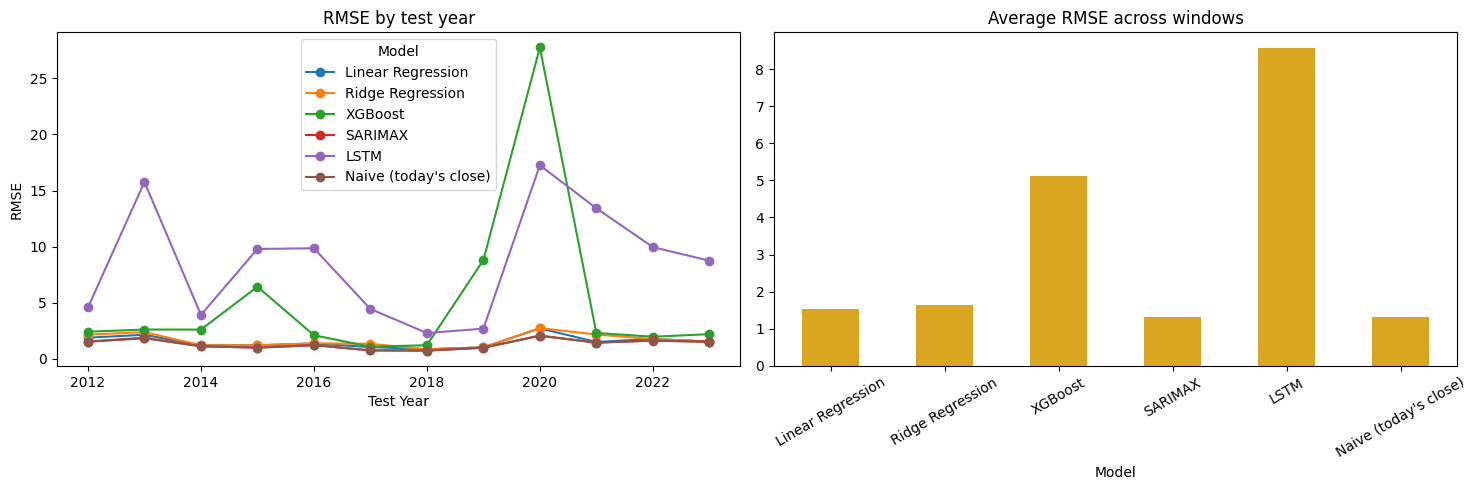

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
piv = results.pivot(index="Test Year", columns="Model", values="RMSE")[order]
piv.plot(marker="o", ax=ax[0]); ax[0].set_title("RMSE by test year"); ax[0].set_ylabel("RMSE")
final.set_index("Model")["RMSE"].plot.bar(ax=ax[1], color="goldenrod")
ax[1].set_title("Average RMSE across windows"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

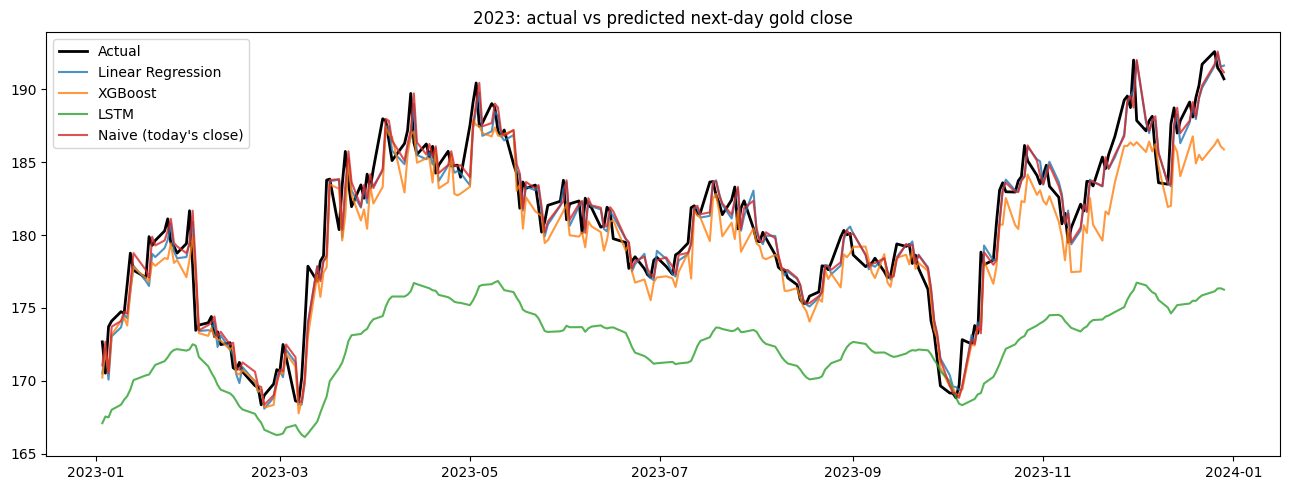

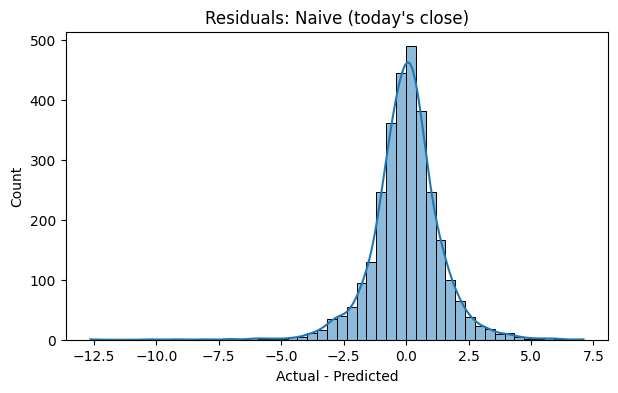

In [16]:
# Actual vs predicted for the 2023 window
fig, ax = plt.subplots(figsize=(13, 5))
d, y, _ = preds_store[(2023, "Linear Regression")]
ax.plot(d, y, label="Actual", color="black", lw=2)
for name in ["Linear Regression", "XGBoost", "LSTM", "Naive (today's close)"]:
    ax.plot(preds_store[(2023, name)][0], preds_store[(2023, name)][2], label=name, alpha=0.8)
ax.set_title("2023: actual vs predicted next-day gold close"); ax.legend(); plt.tight_layout(); plt.show()

# Residuals of the best-MAE model across all windows
best = final.sort_values("MAE").iloc[0]["Model"]
res_all = np.concatenate([preds_store[(y, best)][1] - preds_store[(y, best)][2] for y in range(2012, 2024)])
plt.figure(figsize=(7, 4)); sns.histplot(res_all, bins=50, kde=True)
plt.title(f"Residuals: {best}"); plt.xlabel("Actual - Predicted"); plt.show()

In [17]:
print("Best model by average MAE :", final.sort_values("MAE").iloc[0]["Model"])
print("Best model by average RMSE:", final.sort_values("RMSE").iloc[0]["Model"])
print("Best model by average R²  :", final.sort_values("R²", ascending=False).iloc[0]["Model"])

Best model by average MAE : Naive (today's close)
Best model by average RMSE: Naive (today's close)
Best model by average R²  : Naive (today's close)


## 8. Extension: predict the next-day *change* instead of the price level
Tree models (XGBoost) and LSTMs cannot extrapolate beyond the price range seen in training, which is why they struggle when gold trends to new highs. Predicting `Target - today's close` and adding today's close back removes the trend problem. (For OLS this is mathematically identical to the level model because today's close is already a feature; it changes Ridge, XGBoost and LSTM.)

In [18]:
def with_delta(fn):
    def wrapped(train, test):
        tr = train.copy()
        tr[TARGET] = tr[TARGET] - tr["gold close"]
        return fn(tr, test) + test["gold close"].values
    return wrapped

DELTA_MODELS = {
    "Linear Regression (change)": with_delta(predict_linear),
    "Ridge Regression (change)":  with_delta(predict_ridge),
    "XGBoost (change)":           with_delta(predict_xgb),
    "LSTM (change)":              with_delta(predict_lstm),
}
rows2 = []
for w in windows:
    train, test = get_window(w)
    for name, fn in DELTA_MODELS.items():
        mae, rmse, r2 = metrics(test[TARGET].values, fn(train, test))
        rows2.append({"Test Year": w["test_year"], "Model": name, "MAE": mae, "RMSE": rmse, "R²": r2})
results2 = pd.DataFrame(rows2)
ext = pd.concat([final.set_index("Model").drop(columns="Windows with R² > 0"),
                 results2.groupby("Model")[["MAE","RMSE","R²"]].mean()])
ext.round(4).sort_values("RMSE")

,MAE,RMSE,R²
Model,,,
Naive (today's close),0.9644,1.3140,0.9565
SARIMAX,0.9759,1.3274,0.9560
Ridge Regression (change),1.0008,1.3450,0.9549
XGBoost (change),1.1362,1.4973,0.9418
Linear Regression (change),1.1726,1.5227,0.9422
Linear Regression,1.1726,1.5227,0.9422
Ridge Regression,1.2912,1.6449,0.9233
LSTM (change),1.4681,1.8373,0.8937
XGBoost,4.2030,5.1255,0.3251


## Notes for interpretation
- The **naive baseline** is the bar to beat. Gold is close to a random walk day-to-day, so a model that cannot beat "tomorrow = today" has no real predictive skill, whatever its R².
- **R² on price levels** is misleading in trending data; judge models with MAE/RMSE relative to the naive baseline.
- **2020** (COVID shock) is the hardest window for every model.
- Section 8 shows that predicting the next-day *change* fixes XGBoost and the LSTM, but none of the models beats the naive baseline. A natural next step is richer features (lagged returns, volatility) and directional-accuracy evaluation.